In [8]:
#必要なモジュールのインポート
import boto3 # AWSのサービスを利用するときに必須
import json # json形式のデータを処理する
from PIL import Image # pillow の Image モジュール 画像処理に使用する

In [25]:
file_in = 'sumikko.jpg'
file_out = 'sumikko_out.jpg' # 見つかった顔の部分だけを出力する画像ファイル名

## 顔検出 detect_faces

In [26]:
# rekognition サービスクライアントを作成
rekognition = boto3.client('rekognition')

# 画像ファイルをオープン
with open(file_in, 'rb') as file:
    # 画像ファイルから顔を検出する
    result = rekognition.detect_faces(Image={'Bytes': file.read()})

# 検出結果のjsonを整形して表示
print(json.dumps(result, indent=4))

{
    "FaceDetails": [],
    "ResponseMetadata": {
        "RequestId": "3ea84030-f6c3-4516-9e86-4f18ae10647b",
        "HTTPStatusCode": 200,
        "HTTPHeaders": {
            "x-amzn-requestid": "3ea84030-f6c3-4516-9e86-4f18ae10647b",
            "content-type": "application/x-amz-json-1.1",
            "content-length": "18",
            "date": "Sat, 22 Feb 2025 02:09:40 GMT"
        },
        "RetryAttempts": 0
    }
}


## 見つかった顔の部分だけの画像を作る

In [27]:
# 画像ファイルをオープン
image_in = Image.open(file_in)
# 画像のサイズを取得
w, h = image_in.size

print(w, h)

640 632


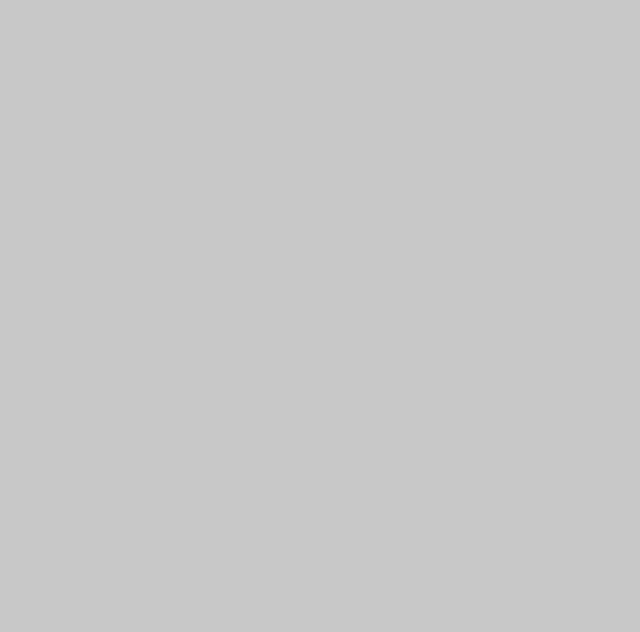

In [28]:
# Imageオブジェクトを生成
image_out = Image.new('RGB', (w, h), (200, 200, 200))

# 動作確認ここから
# 画像をファイルに保存
image_out.save(file_out)

# 画像を表示
image_out.show()
# 動作確認ここまで

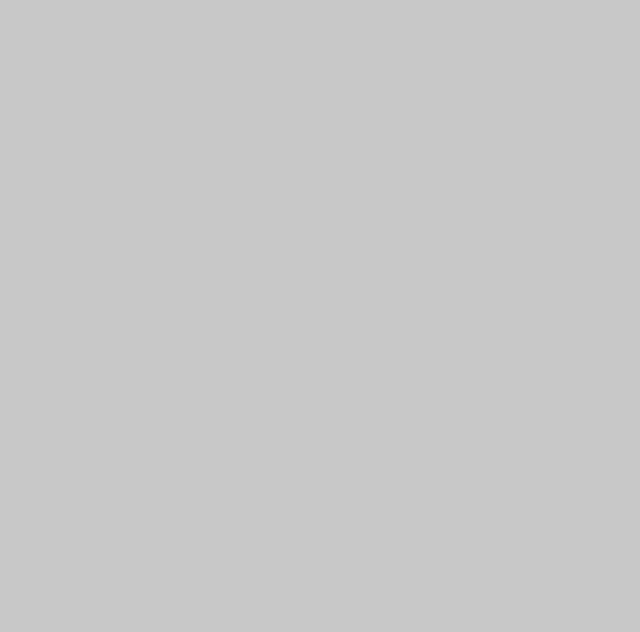

In [29]:
# 検出された顔の分だけ処理を繰り返す
for face in result['FaceDetails']: # 見つかったものはFaceDetailsに含まれる(リスト)
    # バウンディングボックスを取得
    box = face['BoundingBox']

    # jsonでの座標の検出結果は0～1の範囲なので注意
    # 画像での座標は整数にしなければならないので注意
    # 顔の左端の座標を取得
    left = int(box['Left']*w)
    # 顔の上端の座標を取得
    top = int(box['Top']*h)
    # 顔の右端の座標を取得
    right = left+int(box['Width']*w)
    # 顔の下端の座標を取得
    bottom = top+int(box['Height']*h)

    # 入力画像から出力画像に顔の部分を貼り付け
    image_out.paste(
        image_in.crop((left, top, right, bottom)),
        (left, top))

# 画像をファイルに保存
image_out.save(file_out)

# 画像を表示
image_out.show()